<a href="https://colab.research.google.com/github/GraemeGillies/blg-aggregation-adsorption-modelling/blob/main/Gillies_2026_IntDairyJ_blg_kinetics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Collision efficiency extraction for β‑lactoglobulin aggregation

Author: Graeme Gillies  
Affiliation: Fonterra Research and Development Centre  
Correspondence: graeme.gillies@fonterra.com  

This notebook reproduces calculations described in:
"A kinetic framework for β‑lactoglobulin disappearance in heated milk systems"

*code is writen to follow the article and has not be optimised for run time*

ORCID: 0000-0002-1348-3406
Associated publication: [DOI xxxxxx]

``


In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import interpolate
from scipy.optimize import curve_fit
from scipy.stats import linregress
from IPython.display import display

R_gas = 8.314
N_Av = 6.022e23
Boltzmann = 1.381e-23
nm = 10**-9 #nm
pi = np.pi

def viscosity_water_vogel(T_K):
    A = 2.414e-5   # Pa.s
    B = 247.8      # K
    C = 140.0      # K
    return A * 10**(B / (T_K - C))  #Pa.s


# =============================================================================
# GLOBAL MODEL CONSTANTS
# =============================================================================

Mw_blg = 18400        # g/mol, Mw of blg.
r_blg = 2.7 * nm      # m
d_f = 2.0             # fractal dimension of blg protein aggregates
x_max = 40            # max aggregate size


# data and pre-processing

unfolding

In [86]:

# =============================================================================
# Unfolded fraction vs temperature
# Source: A. Tolkach & U. Kulozik (2007), Le Lait
# DOI: 10.1051/lait:2007012
# =============================================================================

# 1. Raw data
data_alpha = {
    'alpha':  [1, 0.8, 0.52, 0.25, 0.12, 0.05, 0.04, 0.02],
    'temp_C': [90, 88, 85, 80, 75, 70, 68, 63],
    'K':       [np.inf, 4, 1.083, 0.333, 0.136, 0.0526, 0.0417, 0.0204]
}

# 2. Raw dataframe (never modified)
df_alpha_raw = pd.DataFrame(data_alpha)

# 3. Full experimental dataset (used for plotting)
df_alpha_full = df_alpha_raw.copy()

# 4. Fit‑eligible subset (transition region only)
# fits are made on data which satisfy  0.1 < alpha < 0.9
df_alpha_fit = df_alpha_full.query("alpha > 0.1 and alpha < 0.9").copy()

# 5. Inspect
print("compelte data set")
display(df_alpha_full)
print("data set used for fitting")
display(df_alpha_fit)



compelte data set


,alpha,temp_C,K
0,1.00,90,inf
1,0.80,88,4.0000
2,0.52,85,1.0830
3,0.25,80,0.3330
4,0.12,75,0.1360
5,0.05,70,0.0526
6,0.04,68,0.0417
7,0.02,63,0.0204


data set used for fitting


,alpha,temp_C,K
1,0.80,88,4.000
2,0.52,85,1.083
3,0.25,80,0.333
4,0.12,75,0.136


denaturation

In [87]:
# =============================================================================
# Denaturation kinetics (soluble β-LG 'loss')
# Source: J. Petit et al. (2011), Journal of Dairy Science
# DOI: 10.3168/jds.2011-4470
# Notes: Pure β-LG solution (no casein micelles). Initial β-LG = 53.3 g/L.
# only no calcium data is used.
# =============================================================================

# -----------------------------
# 1) Raw data (as reported)
# -----------------------------
data_Petit = {
    "time_min": [0, 2, 3, 4, 5, 7, 10,
                 0, 1, 2, 3, 4, 5, 6, 7],
    "Cs0_over_Cs": [
        1.000, 1.186, 1.341, 1.527, 1.776, 2.272, 3.390,
        1.000, 1.519, 3.186, 5.196, 6.568, 8.333, 10.490, 13.627
    ],
    "temp_C": [74.5]*7 + [91]*8,
    "Ca_mM": [0]*15
}

df_den_raw = pd.DataFrame(data_Petit)

# -----------------------------
# 2) System metadata (embedded as columns)
# -----------------------------
# Petit uses 53.3 g/L β-LG solutions.
df_den = df_den_raw.copy()
df_den["source"] = "Petit_2011_JDairySci"
df_den["system_type"] = "blg_solution"            # explicit: not milk
df_den["protein"] = "beta_lactoglobulin"
df_den["Cs0_gL"] = 53.3                            # explicit per-row metadata
df_den["casein_gL"] = 0.0                          # explicit: no casein micelles
df_den["micelles_present"] = False                 # explicit: prevents adsorption logic
df_den["R_CM_nm"] = np.nan                         # not applicable; keeps schema consistent later


# -----------------------------
# 3) Derived quantities (now use Cs0 from the dataframe)
# -----------------------------
df_den["Cs_gL"] = df_den["Cs0_gL"] / df_den["Cs0_over_Cs"]      # soluble monomer conc (g/L)
df_den["monomer_frac"] = df_den["Cs_gL"] / df_den["Cs0_gL"]     # Cs/Cs0 (dimensionless)

# -----------------------------
# 4) Inspect
# -----------------------------
display(df_den)

,time_min,Cs0_over_Cs,temp_C,Ca_mM,source,system_type,protein,Cs0_gL,casein_gL,micelles_present,R_CM_nm,Cs_gL,monomer_frac
0,0,1.000,74.5,0,Petit_2011_JDairySci,blg_solution,beta_lactoglobulin,53.3,0.0,False,NaN,53.300000,1.000000
1,2,1.186,74.5,0,Petit_2011_JDairySci,blg_solution,beta_lactoglobulin,53.3,0.0,False,NaN,44.940978,0.843170
2,3,1.341,74.5,0,Petit_2011_JDairySci,blg_solution,beta_lactoglobulin,53.3,0.0,False,NaN,39.746458,0.745712
3,4,1.527,74.5,0,Petit_2011_JDairySci,blg_solution,beta_lactoglobulin,53.3,0.0,False,NaN,34.905043,0.654879
4,5,1.776,74.5,0,Petit_2011_JDairySci,blg_solution,beta_lactoglobulin,53.3,0.0,False,NaN,30.011261,0.563063
5,7,2.272,74.5,0,Petit_2011_JDairySci,blg_solution,beta_lactoglobulin,53.3,0.0,False,NaN,23.459507,0.440141
6,10,3.390,74.5,0,Petit_2011_JDairySci,blg_solution,beta_lactoglobulin,53.3,0.0,False,NaN,15.722714,0.294985
7,0,1.000,91.0,0,Petit_2011_JDairySci,blg_solution,beta_lactoglobulin,53.3,0.0,False,NaN,53.300000,1.000000
8,1,1.519,91.0,0,Petit_2011_JDairySci,blg_solution,beta_lactoglobulin,53.3,0.0,False,NaN,35.088874,0.658328
9,2,3.186,91.0,0,Petit_2011_JDairySci,blg_solution,beta_lactoglobulin,53.3,0.0,False,NaN,16.729441,0.313873


adsorption kinetics

In [88]:
# =============================================================================
# Adsorption kinetics (whey protein association with casein micelles)
# Source: Anema & Li (2003), J. Agric. Food Chem.
# DOI:
# Notes:
#   - Reconstituted skim milk system
#   - Temperature = 90 °C (subset used here)
#   - Whey protein ~4.5 g/L (typical milk estimate)
#   - Casein ~26 g/L → micelles present
# =============================================================================


# -----------------------------
# 1) Raw data (as reported)
# -----------------------------
data_Anema_Li = {
    "time_min": [0, 2, 4, 6, 8, 10, 15, 20, 30, 45],
    "pH_6_7":   [0.00, 0.00, 0.20, 0.28, 0.31, 0.32, 0.41, 0.39, 0.38, 0.39],
    "pH_6_6":   [0.00, 0.05, 0.22, 0.34, 0.41, 0.47, 0.51, 0.55, 0.54, 0.54],
    "pH_6_55":  [0.00, 0.08, 0.23, 0.35, 0.44, 0.47, 0.56, 0.63, 0.67, 0.71],
    "Native":   [1.000, 0.601, 0.500, 0.303, 0.250,
                 0.186, 0.150, 0.123, 0.093, 0.041],
    "stdev":    [np.nan, 0.027, 0.048, 0.039, 0.026,
                 0.014, 0.010, np.nan, np.nan, np.nan]
}

df_ads_raw = pd.DataFrame(data_Anema_Li)

# -----------------------------
# 2) System metadata (embedded)
# -----------------------------
df_ads = df_ads_raw.copy()

df_ads["source"] = "Anema_2003_JAFC"
df_ads["system_type"] = "milk"
df_ads["protein"] = "whey_protein"

# --- explicitly define composition ---
df_ads["Cs0_gL"] = 4.5        # whey protein ~3–5 g/L in milk
df_ads["casein_gL"] = 26.0    # typical skim milk casein
df_ads["micelles_present"] = True

# --- define experimental conditions ---
df_ads["temperature_C"] = 90.0
df_ads["Ca_mM"] = np.nan      # not explicitly reported / controlled
df_ads["R_CM_nm"] = 100.0     # typical micelle radius (should use radius at temperature of experiment)

# optional: condition identifiers for each pH
df_ads["condition_pH_6_7"]  = "Anema_2003_90C_pH6.7"
df_ads["condition_pH_6_6"]  = "Anema_2003_90C_pH6.6"
df_ads["condition_pH_6_55"] = "Anema_2003_90C_pH6.55"

# -----------------------------
# 3) Derived quantities (optional clarity)
# -----------------------------
# convert "Native" into "denatured fraction" if useful later
df_ads["denatured_frac"] = 1.0 - df_ads["Native"]

# -----------------------------
# 4) Inspect
# -----------------------------
display(df_ads)


,time_min,pH_6_7,pH_6_6,pH_6_55,Native,stdev,source,system_type,protein,Cs0_gL,casein_gL,micelles_present,temperature_C,Ca_mM,R_CM_nm,condition_pH_6_7,condition_pH_6_6,condition_pH_6_55,denatured_frac
0,0,0.00,0.00,0.00,1.000,NaN,Anema_2003_JAFC,milk,whey_protein,4.5,26.0,True,90.0,NaN,100.0,Anema_2003_90C_pH6.7,Anema_2003_90C_pH6.6,Anema_2003_90C_pH6.55,0.000
1,2,0.00,0.05,0.08,0.601,0.027,Anema_2003_JAFC,milk,whey_protein,4.5,26.0,True,90.0,NaN,100.0,Anema_2003_90C_pH6.7,Anema_2003_90C_pH6.6,Anema_2003_90C_pH6.55,0.399
2,4,0.20,0.22,0.23,0.500,0.048,Anema_2003_JAFC,milk,whey_protein,4.5,26.0,True,90.0,NaN,100.0,Anema_2003_90C_pH6.7,Anema_2003_90C_pH6.6,Anema_2003_90C_pH6.55,0.500
3,6,0.28,0.34,0.35,0.303,0.039,Anema_2003_JAFC,milk,whey_protein,4.5,26.0,True,90.0,NaN,100.0,Anema_2003_90C_pH6.7,Anema_2003_90C_pH6.6,Anema_2003_90C_pH6.55,0.697
4,8,0.31,0.41,0.44,0.250,0.026,Anema_2003_JAFC,milk,whey_protein,4.5,26.0,True,90.0,NaN,100.0,Anema_2003_90C_pH6.7,Anema_2003_90C_pH6.6,Anema_2003_90C_pH6.55,0.750
5,10,0.32,0.47,0.47,0.186,0.014,Anema_2003_JAFC,milk,whey_protein,4.5,26.0,True,90.0,NaN,100.0,Anema_2003_90C_pH6.7,Anema_2003_90C_pH6.6,Anema_2003_90C_pH6.55,0.814
6,15,0.41,0.51,0.56,0.150,0.010,Anema_2003_JAFC,milk,whey_protein,4.5,26.0,True,90.0,NaN,100.0,Anema_2003_90C_pH6.7,Anema_2003_90C_pH6.6,Anema_2003_90C_pH6.55,0.850
7,20,0.39,0.55,0.63,0.123,NaN,Anema_2003_JAFC,milk,whey_protein,4.5,26.0,True,90.0,NaN,100.0,Anema_2003_90C_pH6.7,Anema_2003_90C_pH6.6,Anema_2003_90C_pH6.55,0.877
8,30,0.38,0.54,0.67,0.093,NaN,Anema_2003_JAFC,milk,whey_protein,4.5,26.0,True,90.0,NaN,100.0,Anema_2003_90C_pH6.7,Anema_2003_90C_pH6.6,Anema_2003_90C_pH6.55,0.907
9,45,0.39,0.54,0.71,0.041,NaN,Anema_2003_JAFC,milk,whey_protein,4.5,26.0,True,90.0,NaN,100.0,Anema_2003_90C_pH6.7,Anema_2003_90C_pH6.6,Anema_2003_90C_pH6.55,0.959


# Section 4.1 Thermodynamic unfolding models (van't Hoff and Two-state model)

van't Hoff analysis

In [89]:

# =============================================================================
# van’t Hoff analysis (comparison only)
# Uses df_alpha
# =============================================================================

# select usable points (finite, positive K)
mask = np.isfinite(df_alpha_fit['K']) & (df_alpha_fit['K'] > 0)

T_K  = df_alpha_fit.loc[mask, 'temp_C'].values + 273.15
invT = 1.0 / T_K
lnK  = np.log(df_alpha_fit.loc[mask, 'K'].values)

# linear regression: ln K = m (1/T) + b
m, b, r, p, stderr = linregress(invT, lnK)

# thermodynamic parameters
dH_vh = -m * R_gas          # J/mol
dS_vh =  b * R_gas          # J/mol/K

print("van’t Hoff fit (Tolkach):")
print(f"ΔH = {dH_vh/1000:.1f} kJ/mol")
print(f"ΔS = {dS_vh:.1f} J/mol/K")
print(f"R² = {r**2:.3f}")


van’t Hoff fit (Tolkach):
ΔH = 263.1 kJ/mol
ΔS = 737.7 J/mol/K
R² = 0.963


2 state model

In [90]:

# =============================================================================
# Two‑state thermodynamic model
# Fit alpha(T) for df_alpha
# =============================================================================

dCp = 9e3      # J/mol/K (fixed)

#create a function we can use to calculate α later on
def alpha_two_state(T_K, Tm_K, dH):
    """
    Two‑state unfolding with fixed ΔCp
    """
    dG = (
        dH * (1 - T_K / Tm_K)
        - dCp * (Tm_K - T_K + T_K * np.log(T_K / Tm_K))
    )
    K = np.exp(-dG / (R_gas * T_K))
    return K / (1 + K)

# data
T_K = df_alpha_fit['temp_C'].values + 273.15
alpha_obs = np.clip(df_alpha_fit['alpha'].values, 1e-6, 1 - 1e-6)

# initial guesses
Tm0 = 78 + 273.15
dH0 = 2.5e5

# fit
popt, pcov = curve_fit(
    alpha_two_state,
    T_K,
    alpha_obs,
    p0=[Tm0, dH0],
    bounds=([300, 1e4], [380, 1e6]),
    maxfev=10000
)

Tm_fit, dH_fit = popt

print("Two‑state fit:")
print(f"Tm  = {Tm_fit - 273.15:.1f} °C")
print(f"ΔH  = {dH_fit/1000:.1f} kJ/mol")


Two‑state fit:
Tm  = 84.1 °C
ΔH  = 298.2 kJ/mol


plot 2 state vs van't Hoff

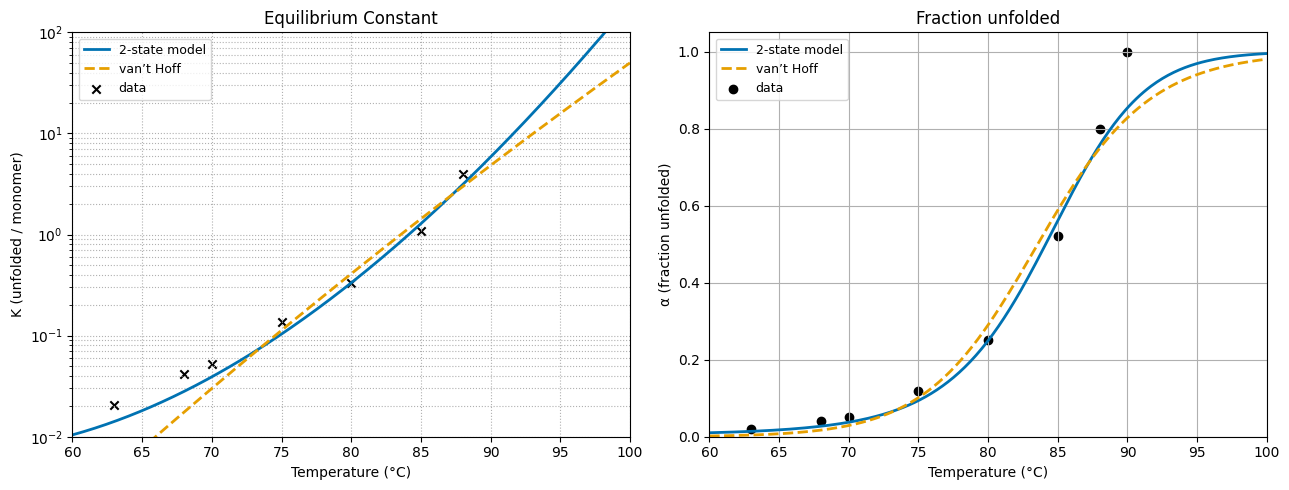

In [91]:
# =============================================================================
# Plot unfolded equilibrium: K(T) and α(T)
# =============================================================================

# Temperature grid for smooth curves
T_plot_C = np.linspace(60, 100, 300)
T_plot_K = T_plot_C + 273.15

# --- Model predictions on grid ---

# Two‑state model
alpha_two = alpha_two_state(T_plot_K, Tm_fit, dH_fit)
K_two = alpha_two / (1 - alpha_two)

# van’t Hoff model (from previous fit)
lnK_vh = m * (1 / T_plot_K) + b
K_vh = np.exp(lnK_vh)
alpha_vh = K_vh / (1 + K_vh)

# =============================================================================
# Plot
# =============================================================================

fig, (axK, axA) = plt.subplots(1, 2, figsize=(13, 5), sharex=True)

# --- Left panel: K(T) ---
# 2 state model
axK.plot(T_plot_C, K_two,
         color="#0072B2", lw=2, label="2‑state model")
# van't Hoff model
axK.plot(T_plot_C, K_vh,
         color="#E69F00", lw=2, ls="--", label="van’t Hoff")
# data
axK.scatter(df_alpha_full['temp_C'],
            df_alpha_full['K'],
            color="black", marker="x", label="data")

#format plot
axK.set_yscale("log")
axK.set_ylim(0.01, 100)
axK.set_xlim(60, 100)
axK.set_xlabel("Temperature (°C)")
axK.set_ylabel("K (unfolded / monomer)")
axK.set_title("Equilibrium Constant")
axK.grid(True, which="both", ls=":")
axK.legend(fontsize=9)

# --- Right panel: α(T) ---
# 2 state model
axA.plot(T_plot_C, alpha_two,
         color="#0072B2", lw=2, label="2‑state model")
# van't Hoff model
axA.plot(T_plot_C, alpha_vh,
         color="#E69F00", lw=2, ls="--", label="van’t Hoff")
# data
axA.scatter(df_alpha_full['temp_C'],
            df_alpha_full['alpha'],
            color="black", label="data")

#format plot
axA.set_xlim(60, 100)
axA.set_ylim(0, 1.05)
axA.set_xlabel("Temperature (°C)")
axA.set_ylabel("α (fraction unfolded)")
axA.set_title("Fraction unfolded")
axA.grid(True)
axA.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Section 4.2 Effects of osmolytes on Tm

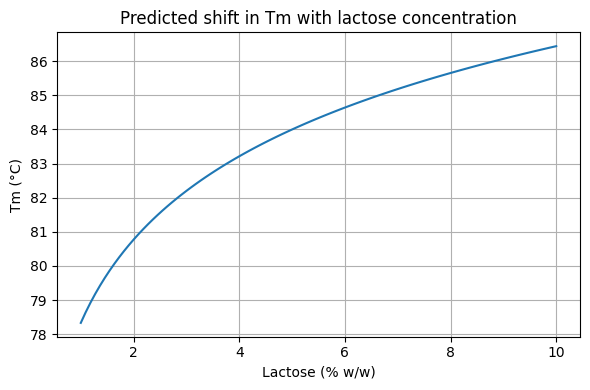

In [92]:


# --- Baseline thermodynamic parameters (Section 4.1) ---
Tm0 = 84.0 + 273.15      # K (baseline Tm ≈ 84 °C)
dH_m = 301e3             # J/mol
R = 8.314                # J/mol/K

# Preferential interaction parameter (Section 4.2)
# ΔΓ ≈ -0.5 to -2 mol sugar/mol protein → use -1 as representative value
delta_Gamma = -1.0

# --- Lactose concentrations (1–10% w/w) ---
lactose_pct = np.linspace(1, 10, 100)

# Convert % w/w → approximate molarity
# 1% ≈ 0.029 g/mL → 0.085 M (lactose MW = 342 g/mol)
lactose_M = lactose_pct * 0.085

# Reference state (e.g. ~5% lactose for UF permeate - estimate onlye)
lactose_ref = 0.085 * 5

# --- Eqn 4.2.1 ---
# ΔTm ≈ −(R Tm^2 / ΔH_m) * ΔΓ * ln(a_s / a_0)
Tm = Tm0 - (R * Tm0**2 / dH_m) * delta_Gamma * np.log(lactose_M / lactose_ref)

# Convert to °C
Tm_C = Tm - 273.15

# --- Plot ---
plt.figure(figsize=(6,4))
plt.plot(lactose_pct, Tm_C)
plt.xlabel("Lactose (% w/w)")
plt.ylabel("Tm (°C)")
plt.title("Predicted shift in Tm with lactose concentration")
plt.grid()
plt.tight_layout()
plt.show()


# Section 4.3 Aggregation kinetics.

first denaturation with no adsorption. Just blg aggregating.

First job is to set up time points to run simulation.
I use increasing step size for efficiency

In [93]:
# =============================================================================
# Time discretisation for aggregation simulation
# Explicit Euler integration with variable time step
#
# change number of points and/or dt_stop for different simulation times
# make sure these changes dont result in errors by running the
# final mass check
# =============================================================================

# --- numerical integration parameters ---
dt_start = 0.01    # s  (small step at early times)
dt_stop  = 0.7985     # s  (larger step at late times)
points   = 10000   # total number of time steps

# --- construct variable time step array ---
dt = np.zeros(points)
dt[1:] = np.geomspace(dt_start, dt_stop, points - 1)

# --- cumulative time axis ---
time_points_sim = np.zeros(points)
for i in range(1, points):
    time_points_sim[i] = time_points_sim[i - 1] + dt[i]

# --- total simulated duration ---
duration_s = time_points_sim[-1]
duration_min = duration_s / 60.0

print(f"Total simulated time will be: {duration_min:.2f} min")


Total simulated time will be: 30.00 min


next set up the experimental variables. The cell below controls everything in the simulation.

In [94]:

# =============================================================================
# Aggregation: define variables for one condition
# =============================================================================

# --------------------------------------------------
# 0) SELECT DATASET (explicit, swappable)
# --------------------------------------------------
data = df_den   # e.g. Petit dataset
# data = df_ads  # later: milk system

# --------------------------------------------------
# 1) SELECT CONDITION (define clearly)
# --------------------------------------------------
T_C = 74.5
df = data[data["temp_C"] == T_C].copy()

# Pull system parameters directly from dataset
Cs0 = float(df["Cs0_gL"].iloc[0])
micelles_present = bool(df["micelles_present"].iloc[0])

# --------------------------------------------------
# 2) THERMODYNAMIC STATE
# --------------------------------------------------
T_K = T_C + 273.15
kT = Boltzmann * T_K

# viscosity
eta = viscosity_water_vogel(T_K)

# unfolded fraction α(T)
# NOTE: pulled from thermodynamic model calculated earlier
alpha = float(alpha_two_state(T_K, Tm_fit, dH_fit))

# ASSUMPTION (important):
# N <-> U interconversion is assumed fast relative to aggregation and adsorption.
# Therefore, at each time step, the monomer pool is maintained at equilibrium:
#     U = alpha * (N + U)
#     N = (1 - alpha) * (N + U)
#
# Physically, this means:
# - adsorption removes unfolded / reactive species
# - but the unfolded pool is continuously replenished by re-equilibration
#
# This is consistent with a thermodynamically controlled unfolding regime.

# --------------------------------------------------
# 3) EXPERIMENTAL DATA (time series)
# --------------------------------------------------
Cs_t = df["Cs_gL"].values
monomer_frac_exp = df["monomer_frac"].values
time_points_exp = df["time_min"].values

# --------------------------------------------------
# 4) CONVERT CONCENTRATION (model units)
# --------------------------------------------------
Cs0_molL = Cs0 / Mw_blg
Cs0_num_m3 = Cs0_molL * 1000 * N_Av

# --------------------------------------------------
# 5) AGGREGATION PARAMETERS
# --------------------------------------------------
W_blg = 0.3e9
collision_efficiency = 1.0 / W_blg

# --------------------------------------------------
# 6) SIGNPOSTING (make system explicit)
# --------------------------------------------------
print("\n" + "*" * 60)
print("Condition selected:")
print("*" * 60)

print(f"Dataset source: {df['source'].iloc[0]}")
print(f"System type: {df['system_type'].iloc[0]}")
print(f"T = {T_C:.1f} °C ({T_K:.2f} K)")
print(f"Water viscosity η(T) = {eta:.3e} Pa·s")
print(f"Unfolded fraction α(T) = {alpha:.3f}  (from thermodynamic model)")
print(f"Initial whey concentration Cs0 = {Cs0:.2f} g/L")

if micelles_present:
    print(f"Casein present: {df['casein_gL'].iloc[0]:.1f} g/L (adsorption enabled)")
else:
    print(f"No casein micelles (pure aggregation system)")

print(f"W = {W_blg:.2e}  (collision efficiency = {collision_efficiency:.2e})")

display(df)



************************************************************
Condition selected:
************************************************************
Dataset source: Petit_2011_JDairySci
System type: blg_solution
T = 74.5 °C (347.65 K)
Water viscosity η(T) = 3.768e-04 Pa·s
Unfolded fraction α(T) = 0.085  (from thermodynamic model)
Initial whey concentration Cs0 = 53.30 g/L
No casein micelles (pure aggregation system)
W = 3.00e+08  (collision efficiency = 3.33e-09)


,time_min,Cs0_over_Cs,temp_C,Ca_mM,source,system_type,protein,Cs0_gL,casein_gL,micelles_present,R_CM_nm,Cs_gL,monomer_frac
0,0,1.000,74.5,0,Petit_2011_JDairySci,blg_solution,beta_lactoglobulin,53.3,0.0,False,NaN,53.300000,1.000000
1,2,1.186,74.5,0,Petit_2011_JDairySci,blg_solution,beta_lactoglobulin,53.3,0.0,False,NaN,44.940978,0.843170
2,3,1.341,74.5,0,Petit_2011_JDairySci,blg_solution,beta_lactoglobulin,53.3,0.0,False,NaN,39.746458,0.745712
3,4,1.527,74.5,0,Petit_2011_JDairySci,blg_solution,beta_lactoglobulin,53.3,0.0,False,NaN,34.905043,0.654879
4,5,1.776,74.5,0,Petit_2011_JDairySci,blg_solution,beta_lactoglobulin,53.3,0.0,False,NaN,30.011261,0.563063
5,7,2.272,74.5,0,Petit_2011_JDairySci,blg_solution,beta_lactoglobulin,53.3,0.0,False,NaN,23.459507,0.440141
6,10,3.390,74.5,0,Petit_2011_JDairySci,blg_solution,beta_lactoglobulin,53.3,0.0,False,NaN,15.722714,0.294985


Next is the aggregation loop.

The way this works is we calculate the 1-1 reaction, 1-2, 1-3, 1-4 ...
then we move onto 2-2, 2-3, 2-4, .... then 3-3, 3-4, 3-5 and so on. just note 1-1, 2-2 and 3-3 get double counted so we add in a correcting 0.5 factor.

At the end, we add up all the blg in different forms and compare with the original amount. This check is a very solid check that the loop is working, and the value should be very small, numerical rounding issues only

In [95]:
# =============================================================================
# Aggregation: population balance with Smoluchowski-type kernel (explicit Euler)
# =============================================================================

# --------------------------------------------------
# compute size-dependent geometry and diffusion (depends on eta, T)
# --------------------------------------------------
R = np.zeros(x_max + 1)
D = np.zeros(x_max + 1)

for i in range(1, x_max + 1):
    R[i] = r_blg * i**(1.0 / d_f)          # cluster radius (meters)
    D[i] = kT / (6.0 * pi * eta * R[i])   # diffusion coeff (m^2/s)

# aggregation kernel (BLG–BLG)
k = np.zeros((x_max + 1, x_max + 1), dtype=float)

prefactor = 2.0 * kT / (3.0 * eta) / W_blg
for i in range(1, x_max + 1):
    for j in range(i, x_max + 1):
        kij = prefactor * ((R[i] + R[j])**2) /  (R[i] * R[j])
        k[i, j] = kij
        k[j, i] = kij


# --- Concentration array: rows = species (0..x_max), cols = time points ---
C_blg = np.zeros((x_max + 1, len(time_points_sim)), dtype=float)
   #C_blg[0,:] is the native protein monomers
   #C_blg[1,:] is the unfolded protein monomers
   #C_blg[x,:] is the aggregates made of x monomers


# Initial condition: split monomers into native (0) and unfolded (1)
C_blg[1, 0] = alpha * Cs0_num_m3
C_blg[0, 0] = Cs0_num_m3 - C_blg[1, 0]

# --- Helper: monomer equivalents (for quick mass conservation check) ---
def total_monomer_equivalents(C_vec):
    tot = C_vec[0]  # monomer monomer counts as 1
    for i in range(1, x_max + 1):
        tot += i * C_vec[i]
    return tot

initial_total = total_monomer_equivalents(C_blg[:, 0])

# =============================================================================
# Time stepping (Euler's method)
# =============================================================================
for t in range(1, len(time_points_sim)):
    dt_step = dt[t]   # variable time step from the dt array

    prev = C_blg[:, t - 1]
    dC = np.zeros(x_max + 1, dtype=float)

    # aggregation: iterate i then j >= i (avoids double counting)
    for i in range(1, x_max + 1):
        Ci = prev[i]
        if Ci <= 0:
            continue

        for j in range(i, x_max + 1):
            Cj = prev[j]
            if Cj <= 0:
                continue

            # event rate for i + j collision
            if i == j:
                rate = 0.5 * k[i, i] * Ci * Cj   # combinatorial 1/2
                dC[i] -= 2.0 * rate              # consumes two i-mers
            else:
                rate = k[i, j] * Ci * Cj
                dC[i] -= rate
                dC[j] -= rate

            dest = i + j

            if dest <= x_max:
                dC[dest] += rate
            else:
                # bin into x_max while conserving monomer equivalents
                dC[x_max] += rate * (dest / float(x_max))

        #end inner loop

    # update concentrations
    C_blg[:, t] = prev + dC * dt_step

    # Rebalance the fast N <-> U equilibrium for monomers (indices 0 and 1 only)
    monomers = C_blg[0, t] + C_blg[1, t]
    C_blg[1, t] = alpha * monomers
    C_blg[0, t] = monomers - C_blg[1, t]

    # end outer loop


# --- final mass check ---
final_total = total_monomer_equivalents(C_blg[:, -1])
delta = (final_total - initial_total) / initial_total
tol = 1e-8

if abs(delta) < tol:
    print(f"Mass conservation check: PASS (Δ = {delta:.3e})")
else:
    print(f"Mass conservation check: FAIL (Δ = {delta:.3e})")


Mass conservation check: PASS (Δ = 5.848e-15)


now plot the simulation, compare against data.

RMSE (monomer fraction) at 74.5 °C = 0.03286


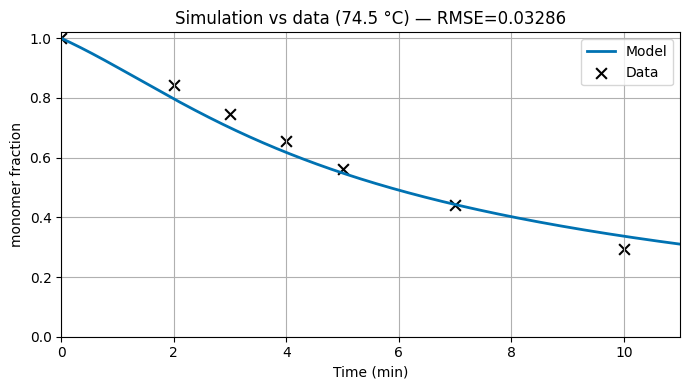

alpha = 0.085


In [96]:

# =============================================================================
# Plot: aggregation simulation vs experimental data (monomer fraction)
# Includes RMSE after interpolating model to experimental times
# =============================================================================


# --- experimental data (from df built in the variable cell) ---
   #remember data defined earlier points
   #time_points_exp = df["time_min"].values            # minutes
   #monomer_frac_exp = df["monomer_frac"].values       # Cs/Cs0 (dimensionless)


# --- model time axis (convert seconds -> minutes for plotting) ---
time_min = time_points_sim / 60.0

# --- model monomer fraction (monomer monomer pool / total monomer equivalents) ---
monomer_sim = ( C_blg[0, :] + C_blg[1, :] ) / Cs0_num_m3         # model monomer fraction vs time


# --- interpolate model to compare model calculation and experimental. ---
interp_model = interpolate.interp1d(
    time_min, monomer_sim,
    bounds_error=False,
    fill_value=(monomer_sim[0], monomer_sim[-1])
)
y_mod_at_exp = interp_model(time_points_exp)


# --- RMSE ---
rmse = np.sqrt(np.mean((y_mod_at_exp - monomer_frac_exp)**2))
print(f"RMSE (monomer fraction) at {T_C:.1f} °C = {rmse:.5f}")


# --- plot ---
plt.figure(figsize=(7,4))

#model line
plt.plot(time_min, monomer_sim,
         color="#0072B2", lw=2, label="Model")

# experimental data
plt.scatter(time_points_exp, monomer_frac_exp,
            color="black", marker="x", s=60, label="Data")

#model values at the exact time as the experimental data
#plt.scatter(time_points_exp, y_mod_at_exp,
#            facecolors="none", edgecolors="#E69F00", s=80,
#            label="Model @ data times")

plt.xlabel("Time (min)")
plt.ylabel("monomer fraction")
plt.title(f"Simulation vs data ({T_C:.1f} °C) — RMSE={rmse:.5f}")
plt.grid(True)
plt.xlim(0, time_points_exp.max()*1.1)
plt.ylim(0, 1.02)
plt.legend()
plt.tight_layout()
plt.show()

print(f"alpha = {alpha:.3f}")


# Section 4.4 Aggregation kinetics with adsorption and possible reactions with k-casein


This section extends the aggregation framework to include:
- adsorption of whey proteins to casein micelles
- a simplified κ-casein interaction pathway

The objective is to examine how competing reactions influence
the availability of adsorption-competent species.


### Model structure

The following processes are included:

1. Aggregation (Smoluchowski-type kernel)
2. Adsorption to casein micelles (diffusion-limited encounter)
3. κ-casein interaction (optional pathway)

Key assumptions:

- κ-casein binds preferentially to monomers and small oligomers (controlable)
- resulting complexes do not participate in adsorption
- binding is treated as irreversible
- kinetic parameters are illustrative (not fitted)

This additional pathway allows testing of a supply-limitation mechanism.


select data here

In [97]:
## =============================================================================
## System / data selection
## =============================================================================

data = df_ads   # milk system (Anema & Li)
T_C = 90.0

df = data[data["temperature_C"] == T_C].copy()

Cs0_gL = float(df["Cs0_gL"].iloc[0])
casein_gL = float(df["casein_gL"].iloc[0])
micelles_present = bool(df["micelles_present"].iloc[0])
R_CM = float(df["R_CM_nm"].iloc[0]) * nm


if micelles_present:
    spec_vol_mL_per_g = 4.4
    rho_hat = (1.0 / spec_vol_mL_per_g) * 1e6   # g/m^3 of protein in micelle volume

    V_CM = (4.0/3.0) * pi * R_CM**3
    m_CM_g = rho_hat * V_CM

    casein_g_m3 = casein_gL * 1000.0
    n_CM = casein_g_m3 / m_CM_g

    A_CM = n_CM * (4.0 * pi * R_CM**2)
else:
    n_CM = 0.0
    A_CM = 0.0


In [98]:
## =============================================================================
## Thermodynamic and transport properties
## =============================================================================

T_K = T_C + 273.15
kT = Boltzmann * T_K
eta = viscosity_water_vogel(T_K)

## NOTE:
## α is defined in the control panel


Control panel for all parameters

In [99]:
## =============================================================================
## CONTROL PANEL — Aggregation / adsorption / κ-casein
## =============================================================================

## --- aggregation ---
W_blg = 2.0e9

## --- adsorption ---
W_ads = W_blg / 200
ads_max = 30
r_ads = 2.3 * nm

## --- κ-casein interaction ---
Ks0_gL = 1.0          # set to 0 to disable reactions, >0 to enable
k_bind_const = 1e-25  #m3 s-1
i_bind_max = 30       #largest aggregate k-casein can bind to, must be smaller than x_max.

## --- thermodynamic state ---
alpha = float(alpha_two_state(T_K, Tm_fit, dH_fit))  # from Section 4.1 fit
alpha = 1.0         # this line manually overides the above line, delete it if you want use calculation from 4.1

## NOTE:
## parameters are illustrative — not fitted

### Interpretation of this configuration

- Aggregation builds clusters over time
- Adsorption removes material from the serum phase
- κ-casein (if enabled) competes by binding reactive species

This creates a competition between:
→ adsorption (surface removal)
→ κ-casein reactions (bulk depletion)

The model tests whether adsorption is supply-limited.

In [100]:

## =============================================================================
## Aggregation kernel (Smoluchowski-type, diffusion-limited)
## =============================================================================

# --------------------------------------------------
# compute size-dependent geometry and diffusion (depends on eta, T)
# --------------------------------------------------
R = np.zeros(x_max + 1)
D = np.zeros(x_max + 1)

for i in range(1, x_max + 1):
    R[i] = r_blg * i**(1.0 / d_f)          # cluster radius (meters)
    D[i] = kT / (6.0 * pi * eta * R[i])   # diffusion coeff (m^2/s)

# Preallocate kernel matrix
k = np.zeros((x_max + 1, x_max + 1), dtype=float)

# Prefactor: diffusion-controlled collision rate scaled by W
prefactor = (2.0 * kT) / (3.0 * eta * W_blg)

# Compute pairwise aggregation rates
for i in range(1, x_max + 1):
    for j in range(i, x_max + 1):

        # Smoluchowski kernel:
        kij = prefactor * ((R[i] + R[j])**2) / (R[i] * R[j])

        # Symmetric matrix
        k[i, j] = kij
        k[j, i] = kij

# --- Helper: monomer equivalents (for quick mass conservation check) ---
def total_monomer_equivalents_including_ads_and_complex(C_vec, N_ads, C_complex_vec):
    """
    Returns total BLG monomer equivalents (number per m^3) across:
      - bulk species C_vec (index 0 = native monomer, index i = i-mer)
      - adsorbed population (N_ads) already expressed as monomer equivalents
      - BLG-κ-casein complexes in C_complex_vec (index i = complex of size i)
    Note: N_ads should be monomer-equivalent count (i.e. sum(i * C_ads_pop[i])).
    """
    tot = C_vec[0]   # native monomer count
    for i in range(1, x_max + 1):
        tot += i * C_vec[i]           # bulk aggregates
        tot += i * C_complex_vec[i]   # BLG tied up in κ-casein complexes
    tot += N_ads                       # adsorbed monomer equivalents
    return tot

## Notes:
## - assumes spherical fractal aggregates
## - diffusion-limited encounter rate scaled by W_blg
## - identical W used across all aggregation steps (lumped assumption)

## =============================================================================
## Adsorption kernel (diffusion-limited collision with micelles)
## =============================================================================

# Preallocate adsorption rates (only up to ads_max)
k_ads = np.zeros(ads_max + 1)

adsorption_enabled = micelles_present and (ads_max > 0)

if adsorption_enabled:


    #Common prefactor (adsorption)
    prefactor_ads = (2.0 * kT) / (3.0 * eta * W_ads)

    for i in range(1, ads_max + 1):

        k_ads[i] = prefactor_ads * ((R[i] + R_CM)**2) / (R[i] * R_CM)


# =============================================================================
# Blocking function B(theta): placeholder (currently no blocking)
# =============================================================================

theta_max = 0.55   # RSA jamming limit for small spheres on a large sphere
m_block  = 3.0     # geometric exponent (Talbot/Vans Tassel style)

def blocking(theta):
    """
    Steric blocking factor B(theta).

    CURRENT IMPLEMENTATION (for clarity / SI baseline):
        return 1.0  # i.e., no blocking under all conditions

    OPTIONAL:
        B = (1 - theta/theta_max)**m_block, clipped to [0,1]
    """
    return 1.0
    # --- optional RSA-style form (disabled for now) ---
    # x = max(0.0, (1.0 - theta/theta_max)**m_block)
    # return x**m_block

## Notes:
## - adsorption treated as diffusion-controlled collision with micelle
## - scaled by W_ads (effective sticking probability)
## - only aggregates up to size ads_max are allowed to adsorb
## - larger aggregates remain in bulk phase
## - adsorption removes species from solution, reducing bulk concentration
##   → competes with aggregation and (if enabled) κ-casein depletion


In [101]:
## =============================================================================
## κ-casein interaction model
## =============================================================================

## convert concentration
Mw_kappa = 19900.0
Ks0_molL = Ks0_gL / Mw_kappa
Ks0_num_m3 = Ks0_molL * 1000 * N_Av

## free κ-casein pool
K_free = np.zeros(len(time_points_sim))
K_free[0] = Ks0_num_m3

## complexes
C_blgK = np.zeros((x_max + 1, len(time_points_sim)))

## interpretation:
## κ-casein binding removes adsorption-competent species
## → acts as a depletion pathway


In [102]:
## =============================================================================
## Initial conditions
## =============================================================================

# --- Convert initial concentration (whey protein) ---
Cs0_molL = Cs0_gL / Mw_blg
Cs0_num_m3 = Cs0_molL * 1000.0 * N_Av   # number concentration (m^-3)

# --- Allocate state arrays ---
# C_blg: bulk species (0 = native monomer, 1 = unfolded monomer, i >= 2 = aggregates)
C_blg = np.zeros((x_max + 1, len(time_points_sim)))

# put protein into the array as native (N / folded) and unfolded (U) monomer but no aggregates
C_blg[1, 0] = alpha * Cs0_num_m3
C_blg[0, 0] = Cs0_num_m3 - C_blg[1, 0]


# C_ads_pop: adsorbed population by aggregate size
C_ads_pop = np.zeros((ads_max + 1, len(time_points_sim)))

# N_ads_tot: total number of adsorbed monomer equivalents
N_ads_tot = np.zeros(len(time_points_sim))

# Surface quantities
theta = np.zeros(len(time_points_sim))          # fractional coverage
Gamma_mg_m2 = np.zeros(len(time_points_sim))    # mass-based surface loading

# -----------------------------------------------------------------------------


In [103]:
## =============================================================================
## Time stepping (aggregation + adsorption + κ-casein)
## =============================================================================


## At each timestep, the model applies:
## 1. aggregation (bulk growth)
## 2. adsorption (surface removal)
## 3. κ-casein binding (depletion)
## followed by:
## → equilibrium redistribution (N ↔ U)
## → surface bookkeeping


for t in range(1, len(time_points_sim)):

    dt_step = dt[t]

    # -------------------------------------------------------------------------
    # 1. RESET RATE BUFFERS (per time step)
    # -------------------------------------------------------------------------

    dC_blg = np.zeros(x_max + 1)         # bulk updates
    dC_ads = np.zeros(ads_max + 1)       # adsorption updates
    dC_blgK = np.zeros(x_max + 1)        # κ-casein complex updates

    # shorthand for current state
    C = C_blg[:, t-1]
    C_complex = C_blgK[:, t-1]
    Kf = K_free[t-1]


    # -------------------------------------------------------------------------
    # 2. AGGREGATION (bulk Smoluchowski population balance)
    # -------------------------------------------------------------------------
    # binary collisions between all aggregates

    for i in range(1, x_max + 1):
        for j in range(i, x_max + 1):

            if i + j > x_max:
                continue

            rate = k[i, j] * C[i] * C[j]

            if i == j:
                rate *= 0.5   # avoid double counting

            # loss of i and j
            dC_blg[i] -= rate * dt_step
            dC_blg[j] -= rate * dt_step

            # formation of new aggregate
            dC_blg[i + j] += rate * dt_step


    # -------------------------------------------------------------------------
    # 3. ADSORPTION (removal to micelle surface)
    # -------------------------------------------------------------------------
    # only applies if micelles present

    if adsorption_enabled:

        theta_now = theta[t-1]

        for i in range(1, ads_max + 1):

            # adsorption rate
            r_ads_i = k_ads[i] * C[i] * n_CM * blocking(theta_now)

            flux = r_ads_i * dt_step

            # remove from bulk
            dC_blg[i] -= flux

            # add to adsorbed population
            dC_ads[i] += flux


    # -------------------------------------------------------------------------
    # 4. κ-casein binding (depletion pathway)
    # -------------------------------------------------------------------------
    # removes adsorption-competent species from solution

    if Ks0_gL > 0:

        for i in range(1, i_bind_max + 1):

            # binding rate (lumped)
            r_bind = k_bind_const * C[i] * Kf

            flux = r_bind * dt_step

            # remove from BLG
            dC_blg[i] -= flux

            # form complex
            dC_blgK[i] += flux

            # deplete free κ-casein
            Kf -= flux


    # -------------------------------------------------------------------------
    # 5. UPDATE STATE VARIABLES
    # -------------------------------------------------------------------------

    C_blg[:, t] = C + dC_blg
    C_ads_pop[:, t] = C_ads_pop[:, t-1] + dC_ads
    C_blgK[:, t] = C_complex + dC_blgK
    K_free[t] = Kf


    # -------------------------------------------------------------------------
    # 6. MAINTAIN N ⇌ U EQUILIBRIUM
    # -------------------------------------------------------------------------
    # fast unfolding assumption: redistribute monomer pool

    monomer_total = C_blg[0, t] + C_blg[1, t]

    C_blg[1, t] = alpha * monomer_total
    C_blg[0, t] = (1 - alpha) * monomer_total


    # -------------------------------------------------------------------------
    # 7. SURFACE BOOKKEEPING
    # -------------------------------------------------------------------------

    if adsorption_enabled:

        # total adsorbed (monomer equivalents)
        N_ads_tot[t] = np.sum(
            np.arange(ads_max + 1) * C_ads_pop[:, t]
        )

        Gamma_mg_m2[t] = (N_ads_tot[t] / N_Av) * Mw_blg * 1000.0 / A_CM

        # surface coverage
        theta[t] = (N_ads_tot[t] * np.pi * r_ads**2) / A_CM

    else:
        N_ads_tot[t] = 0.0
        theta[t] = 0.0



# --- final mass check ---
initial_total_all = total_monomer_equivalents_including_ads_and_complex(
    C_blg[:, 0], N_ads_tot[0], C_blgK[:, 0])
final_total_all = total_monomer_equivalents_including_ads_and_complex(
    C_blg[:, -1], N_ads_tot[-1], C_blgK[:, -1])

delta = (final_total_all - initial_total_all) / initial_total_all

if abs(delta) < 1e-8:
    print(f"Mass conservation: PASS (Δ = {delta:.3e})")
else:
    print(f"Mass conservation: FAIL (Δ = {delta:.3e})")

Mass conservation: PASS (Δ = -7.974e-16)


In [104]:
## =============================================================================
## RUN SUMMARY (for plotted results)
## =============================================================================

print("\n" + "="*60)
print("Simulation summary")
print("="*60)

print(f"T = {T_C:.1f} °C")
print(f"alpha = {alpha:.2f}")
print(f"W_blg = {W_blg:.2e}")
print(f"W_ads = {W_ads:.2e}")
print(f"laregset aggreagte considered = {x_max}")
print(f"largest adsorbable aggregate = {ads_max}")
print("")
print(f"Cs0 = {Cs0_gL:.2f} g/L")
print(f"micelles_present = {micelles_present}")
if micelles_present:
    print(f"R_CM = {R_CM/nm:.1f} nm  |  casein = {casein_gL:.1f} g/L")
    print(f"n_CM = {n_CM:.3e} m^-3  |  A_CM = {A_CM:.3e} m^2 m^-3")
print(f"W_blg = {W_blg:.2e}  |  W_ads = {W_ads:.2e}  |  ads_max = {ads_max}")

print("\nκ-casein:")
print(f"Ks0 = {Ks0_gL:.2f} g/L")
print(f"k_bind = {k_bind_const:.2e}")

if Ks0_gL == 0:
    print("→ κ-casein reactions DISABLED")
    print("Scenario: aggregation + adsorption only")
else:
    print("→ κ-casein reactions ACTIVE")
    print("Scenario: κ-casein-mediated depletion")

print("="*60)


Simulation summary
T = 90.0 °C
alpha = 1.00
W_blg = 2.00e+09
W_ads = 1.00e+07
laregset aggreagte considered = 40
largest adsorbable aggregate = 30

Cs0 = 4.50 g/L
micelles_present = True
R_CM = 100.0 nm  |  casein = 26.0 g/L
n_CM = 2.731e+19 m^-3  |  A_CM = 3.432e+06 m^2 m^-3
W_blg = 2.00e+09  |  W_ads = 1.00e+07  |  ads_max = 30

κ-casein:
Ks0 = 1.00 g/L
k_bind = 1.00e-25
→ κ-casein reactions ACTIVE
Scenario: κ-casein-mediated depletion


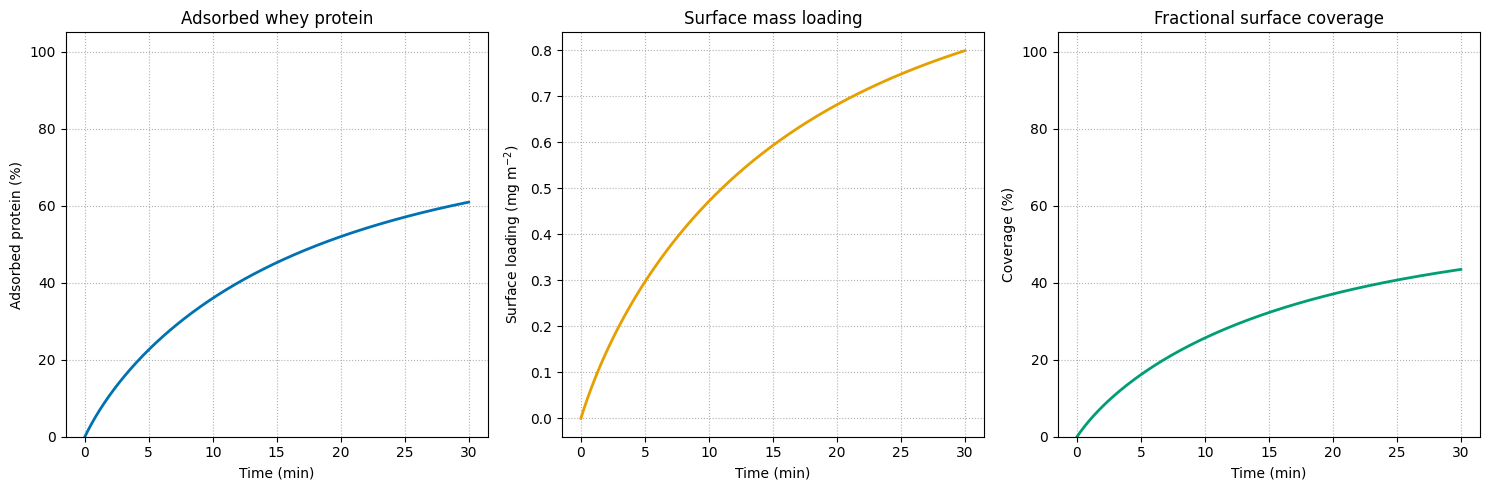

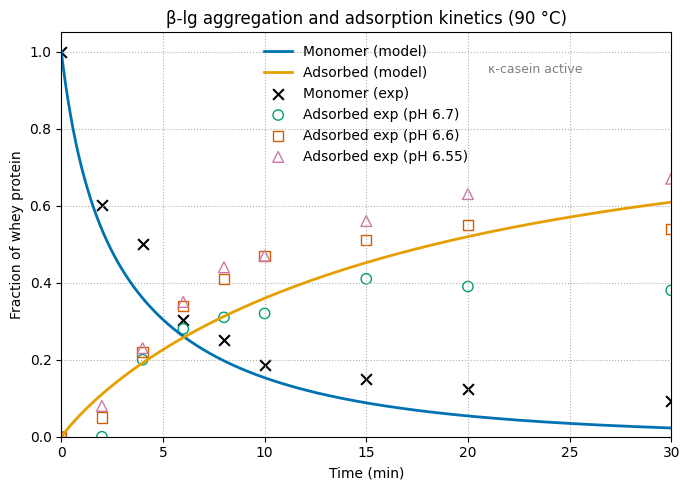

In [105]:

## =============================================================================
## Results: adsorption metrics
## =============================================================================

# Convert simulation time to minutes for plotting
time_min = time_points_sim / 60.0

# Create figure
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# -------------------------------------------------------------------------
# 1. Total whey protein adsorbed (% of initial whey protein)
# -------------------------------------------------------------------------

protein_ads_percent = (N_ads_tot / Cs0_num_m3) * 100.0

ax1.plot(time_min, protein_ads_percent, color="#0072B2", lw=2)
ax1.set_title("Adsorbed whey protein")
ax1.set_xlabel("Time (min)")
ax1.set_ylabel("Adsorbed protein (%)")
ax1.set_ylim(0, 105)
ax1.grid(True, ls=":")

# -------------------------------------------------------------------------
# 2. Surface mass loading (mg m^-2)
# -------------------------------------------------------------------------

surface_coverage = (N_ads_tot / N_Av) * Mw_blg * 1000.0 / A_CM

ax2.plot(time_min, surface_coverage, color="#E69F00", lw=2)
ax2.set_title("Surface mass loading")
ax2.set_xlabel("Time (min)")
ax2.set_ylabel("Surface loading (mg m$^{-2}$)")
ax2.grid(True, ls=":")

# -------------------------------------------------------------------------
# 3. Fractional surface coverage (%)
# -------------------------------------------------------------------------

fraction_coverage = (N_ads_tot * np.pi * r_ads**2) / A_CM
theta_percent = fraction_coverage * 100.0

ax3.plot(time_min, theta_percent, color="#009E73", lw=2)
ax3.set_title("Fractional surface coverage")
ax3.set_xlabel("Time (min)")
ax3.set_ylabel("Coverage (%)")
ax3.set_ylim(0, 105)
ax3.grid(True, ls=":")

# -------------------------------------------------------------------------
# Layout
# -------------------------------------------------------------------------

plt.tight_layout()
plt.show()


## =============================================================================
## Results: monomer + adsorption comparison
## =============================================================================

# Convert simulation time to minutes
time_min = time_points_sim / 60.0

# --- Model outputs ---
monomer_sim = (C_blg[0, :] + C_blg[1, :]) / Cs0_num_m3
adsorbed_frac = N_ads_tot / Cs0_num_m3

# --- Create figure ---
plt.figure(figsize=(7, 5))

# ============================================================================
# Model results
# ============================================================================

plt.plot(
    time_min,
    monomer_sim,
    color="#0072B2",
    lw=2,
    label="Monomer (model)"
)

plt.plot(
    time_min,
    adsorbed_frac,
    color="#E69F00",
    lw=2,
    label="Adsorbed (model)"
)

# ============================================================================
# Experimental data
# ============================================================================

# Native/soluble whey protein
plt.scatter(
    df_ads["time_min"],
    df_ads["Native"],
    color="black",
    marker="x",
    s=60,
    label="Monomer (exp)"
)

# Adsorbed protein (pH series)
plt.scatter(
    df_ads["time_min"],
    df_ads["pH_6_7"],
    marker="o",
    facecolors="none",
    edgecolors="#009E73",
    s=55,
    label="Adsorbed exp (pH 6.7)"
)

plt.scatter(
    df_ads["time_min"],
    df_ads["pH_6_6"],
    marker="s",
    facecolors="none",
    edgecolors="#D55E00",
    s=55,
    label="Adsorbed exp (pH 6.6)"
)

plt.scatter(
    df_ads["time_min"],
    df_ads["pH_6_55"],
    marker="^",
    facecolors="none",
    edgecolors="#CC79A7",
    s=60,
    label="Adsorbed exp (pH 6.55)"
)

# ============================================================================
# Formatting
# ============================================================================

plt.xlabel("Time (min)")
plt.ylabel("Fraction of whey protein")
plt.title("β-lg aggregation and adsorption kinetics (90 °C)")


if Ks0_gL > 0:
    plt.annotate(
        "κ-casein active",
        xy=(0.7, 0.9),
        xycoords="axes fraction",
        fontsize=9,
        color="gray"
    )


plt.xlim(0, time_min.max())
plt.ylim(0, 1.05)

plt.grid(True, ls=":")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()



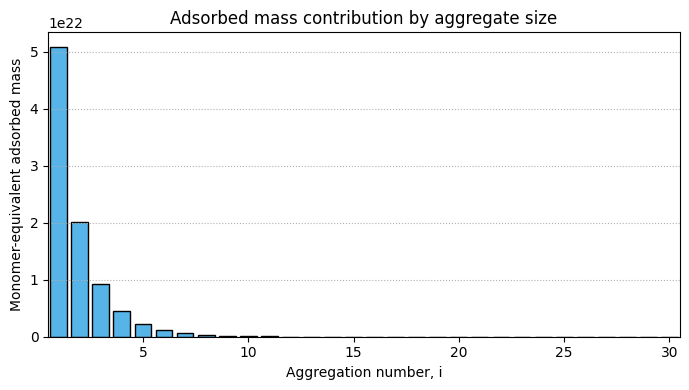

In [106]:
## =============================================================================
## Results: adsorbed mass distribution by aggregate size
## =============================================================================

# Final adsorbed aggregates per size (number concentration)
ads_by_size_final = C_ads_pop[:, -1].copy()   # index 0 unused

# Monomer-equivalent adsorbed mass by size
sizes = np.arange(0, ads_max + 1)
monomer_eq_ads_by_size = sizes * ads_by_size_final

# Optional: fractional contribution of each size class
total_ads_monomer_eq = monomer_eq_ads_by_size.sum()
if total_ads_monomer_eq > 0:
    frac_ads_by_size = monomer_eq_ads_by_size / total_ads_monomer_eq
else:
    frac_ads_by_size = np.zeros_like(monomer_eq_ads_by_size)

# -------------------------------------------------------------------------
# Plot 1: monomer-equivalent adsorbed mass vs aggregate size
# -------------------------------------------------------------------------

plt.figure(figsize=(7, 4))

plt.bar(
    sizes[1:],                      # omit index 0
    monomer_eq_ads_by_size[1:],
    color="#56B4E9",
    edgecolor="black",
    width=0.8
)

plt.xlabel("Aggregation number, i")
plt.ylabel("Monomer-equivalent adsorbed mass")
plt.title("Adsorbed mass contribution by aggregate size")
plt.xlim(0.5, ads_max + 0.5)
plt.grid(True, axis="y", ls=":")
plt.tight_layout()
plt.show()


In [107]:
# @title
# Save model calculations to CSV with a commented header (Colab-friendly)
from datetime import datetime

# Colab download helper
try:
    from google.colab import files
except Exception:
    files = None

# --- Gather / validate model arrays ---
try:
    time_min = time_points_sim / 60.0
    monomer_sim = (C_blg[0, :] + C_blg[1, :]) / Cs0_num_m3
    adsorbed_frac = N_ads_tot / Cs0_num_m3
except NameError as e:
    raise NameError(f"Missing variable in workspace: {e}. Run the simulation cells first.") from e

# Ensure 1D numpy arrays and consistent length
time_min = np.asarray(time_min).reshape(-1)
L = len(time_min)

def as_length(arr, name):
    a = np.asarray(arr).reshape(-1)
    if len(a) == L:
        return a
    if a.size == 1:
        return np.full(L, a.item())
    raise ValueError(f"Array '{name}' length {len(a)} does not match time vector length {L}.")

monomer_sim = as_length(monomer_sim, "monomer_sim")
adsorbed_frac = as_length(adsorbed_frac, "adsorbed_frac")

# --- Build output DataFrame ---
df_out = pd.DataFrame({
    "time_min": time_min,
    "monomer_sim": monomer_sim,
    "adsorbed_frac": adsorbed_frac,
})


# --- Construct a commented header with simulation details ---
def safe_get(var_name, default=None):
    return globals().get(var_name, default)

# Dataset source (try df first, then df_ads)
dataset_source = None
if 'df' in globals():
    try:
        if 'source' in df.columns and len(df) > 0:
            dataset_source = str(df['source'].iloc[0])
    except Exception:
        pass
if dataset_source is None and 'df_ads' in globals():
    try:
        if 'source' in df_ads.columns and len(df_ads) > 0:
            dataset_source = str(df_ads['source'].iloc[0])
    except Exception:
        pass

T_C = safe_get('T_C')
eta = safe_get('eta')
alpha = safe_get('alpha')
Cs0_gL = safe_get('Cs0_gL')
micelles_present = safe_get('micelles_present')
R_CM = safe_get('R_CM')
nm = safe_get('nm')  # unit conversion (meters per nanometer) if defined
casein_gL = safe_get('casein_gL')
n_CM = safe_get('n_CM')
A_CM = safe_get('A_CM')
W_blg = safe_get('W_blg')
W_ads = safe_get('W_ads')
ads_max = safe_get('ads_max')

header_lines = []
header_lines.append("# " + "="*60)
header_lines.append("# Section 4.3 setup")
header_lines.append("# " + "="*60)
if dataset_source is not None:
    header_lines.append(f"# Dataset source: {dataset_source}")
if T_C is not None and eta is not None:
    header_lines.append(f"# T = {T_C:.1f} °C  |  eta = {eta:.3e} Pa·s")
elif T_C is not None:
    header_lines.append(f"# T = {T_C:.1f} °C")
elif eta is not None:
    header_lines.append(f"# eta = {eta:.3e} Pa·s")
if alpha is not None:
    header_lines.append(f"# alpha(T) = {alpha:.3f}  (from thermodynamic model fit)")
if Cs0_gL is not None:
    header_lines.append(f"# Cs0 = {Cs0_gL:.2f} g/L")
if micelles_present is not None:
    header_lines.append(f"# micelles_present = {micelles_present}")
    if micelles_present:
        # R_CM in nm if possible, otherwise show meters
        if (R_CM is not None) and (nm is not None) and (nm != 0):
            header_lines.append(f"# R_CM = {R_CM/nm:.1f} nm  |  casein = {casein_gL:.1f} g/L" if casein_gL is not None else f"# R_CM = {R_CM/nm:.1f} nm")
        elif R_CM is not None:
            header_lines.append(f"# R_CM = {R_CM:.3e} m" + (f"  |  casein = {casein_gL:.1f} g/L" if casein_gL is not None else ""))
        elif casein_gL is not None:
            header_lines.append(f"# casein = {casein_gL:.1f} g/L")
        if n_CM is not None and A_CM is not None:
            header_lines.append(f"# n_CM = {n_CM:.3e} m^-3  |  A_CM = {A_CM:.3e} m^2 m^-3")
        elif n_CM is not None:
            header_lines.append(f"# n_CM = {n_CM:.3e} m^-3")
        elif A_CM is not None:
            header_lines.append(f"# A_CM = {A_CM:.3e} m^2 m^-3")
if W_blg is not None or W_ads is not None or ads_max is not None:
    parts = []
    if W_blg is not None:
        parts.append(f"W_blg = {W_blg:.2e}")
    if W_ads is not None:
        parts.append(f"W_ads = {W_ads:.2e}")
    if ads_max is not None:
        parts.append(f"ads_max = {ads_max}")
    header_lines.append("# " + "  |  ".join(parts))
header_lines.append(f"# Exported: {datetime.utcnow().isoformat(timespec='seconds')}Z")
header_lines.append("# " + "-"*60)
header_lines.append("# Columns below: time_min, monomer_sim, adsorbed_frac, [experimental columns if present]")
header_lines.append("# " + "-"*60)


# --- κ-casein parameters ---
Ks0_gL = safe_get('Ks0_gL')
k_bind_const = safe_get('k_bind_const')

# determine enabled/disabled
kcasein_enabled = (Ks0_gL is not None) and (Ks0_gL > 0)

# consistent formatting (use "-" if disabled or missing)
if kcasein_enabled:
    ks0_str = f"{Ks0_gL:.2f}"
    k_bind_str = f"{k_bind_const:.2e}" if k_bind_const is not None else "-"
    enabled_str = "True"
else:
    ks0_str = "-"
    k_bind_str = "-"
    enabled_str = "False"

header_lines.append("# " + "-"*60)
header_lines.append("# kappa-casein reactions")
header_lines.append("# " + "-"*60)
header_lines.append(f"# kappa-casein enabled = {enabled_str}")
header_lines.append(f"# Ks0 (g/L) = {ks0_str}")
header_lines.append(f"# k_bind_const = {k_bind_str}")


# --- Save with header then CSV data ---
filename = "model_calculations_with_header.csv"
with open(filename, "w", encoding="utf-8") as f:
    for line in header_lines:
        f.write(line + "\n")
    df_out.to_csv(f, index=False)

print(f"Saved {filename} ({df_out.shape[0]} rows, {df_out.shape[1]} data columns + commented header)")

# Trigger download in Colab
if files is not None:
    try:
        files.download(filename)
    except Exception as e:
        print("files.download failed (this can happen for large files). The file is saved at /content.")
else:
    print("Not running in Colab; file saved to current working directory.")

Saved model_calculations_with_header.csv (10000 rows, 3 data columns + commented header)


/tmp/ipykernel_2939/1705759388.py:116: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  header_lines.append(f"# Exported: {datetime.utcnow().isoformat(timespec='seconds')}Z")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>